# Analysis of S&P 500 closing prices using RNN Models

## 1. Importing required libraries

In [1]:
# Data analysis libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

# For deep learning
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, GRU, SimpleRNN, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import math

In [2]:
# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

## 2. Downloading 5 years of S&P 500 data

In [3]:
# Calculating date range for 5 years
end_date = datetime.now()
start_date = end_date - timedelta(days=5*365 + 2)  # Adding 2 days for leap years

# Downloading S&P 500 data
ticker = "^GSPC"
sp500_data = yf.download(ticker, start=start_date, end=end_date)

[*********************100%***********************]  1 of 1 completed


In [4]:
# Set closing prices as the target variable
data = sp500_data[['Close']].copy()
data.columns = ['Price']
data = data.dropna() # Dropping any rows with NaN values (e.g., weekends, holidays)

print(f"Downloaded {len(data)} data points")
print(f"Date range: {data.index[0].strftime('%Y-%m-%d')} to {data.index[-1].strftime('%Y-%m-%d')}")
print(f"Price range: ${data['Price'].min():.2f} to ${data['Price'].max():.2f}")

Downloaded 1256 data points
Date range: 2020-08-24 to 2025-08-22
Price range: $3236.92 to $6468.54


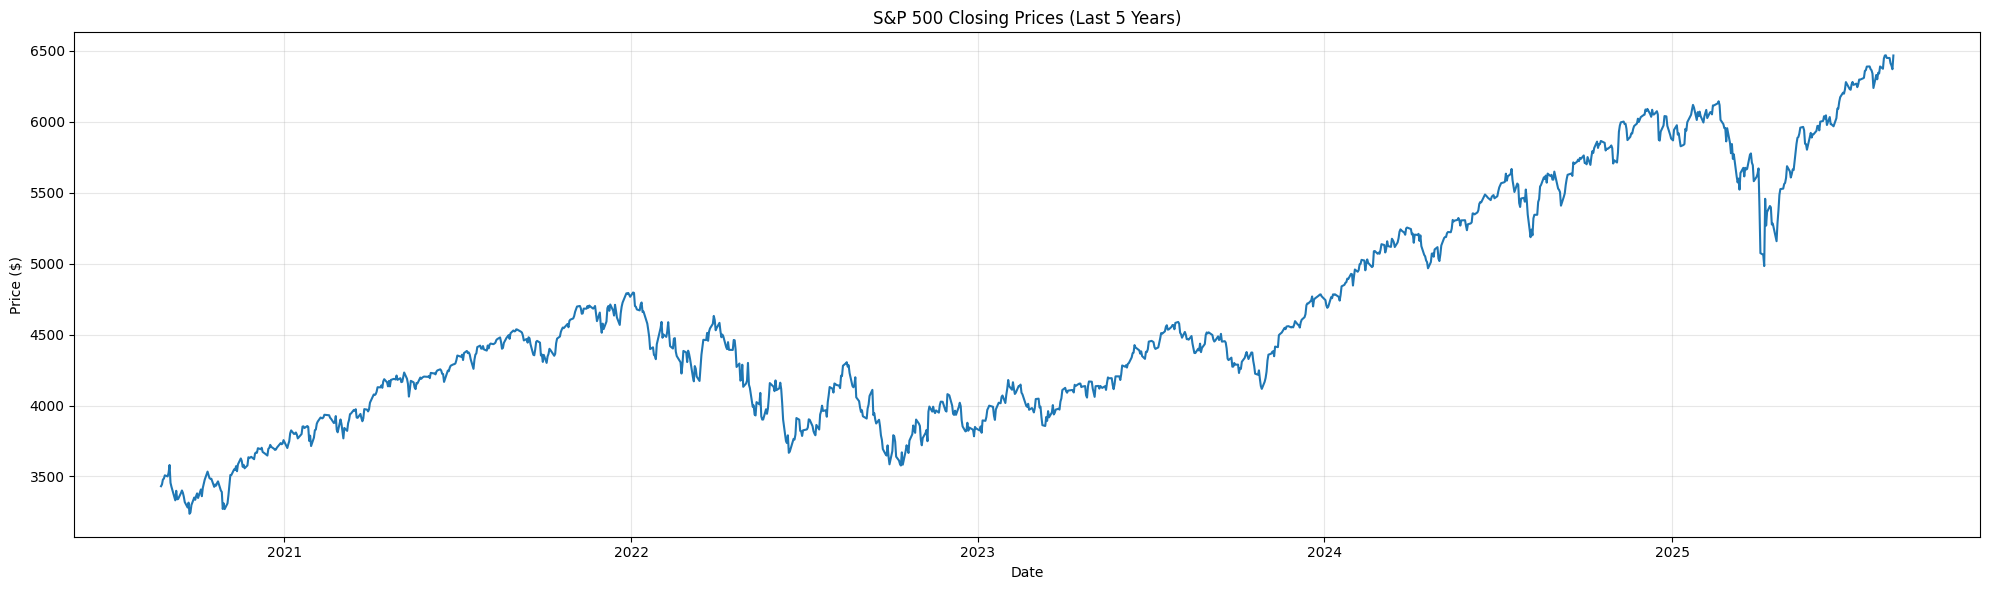

In [5]:
### Visualizing the S&P 500 Closing Prices
plt.figure(figsize=(20, 6))
plt.plot(data.index, data['Price'], linewidth=1.5)
plt.title('S&P 500 Closing Prices (Last 5 Years)')
plt.xlabel('Date')
plt.ylabel('Price ($)')
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.show()

## 3. Creating 80/20 split (with last 20% for testing)

In [6]:
total_samples = len(data)
train_size = int(0.8 * total_samples)
test_size = total_samples - train_size

train_data = data.iloc[:train_size].copy()
test_data = data.iloc[train_size:].copy()

print(f"Total samples: {total_samples}")
print(f"Training samples: {len(train_data)} ({len(train_data)/total_samples*100:.1f}%)")
print(f"Testing samples: {len(test_data)} ({len(test_data)/total_samples*100:.1f}%)")
print(f"Train period: {train_data.index[0].strftime('%Y-%m-%d')} to {train_data.index[-1].strftime('%Y-%m-%d')}")
print(f"Test period: {test_data.index[0].strftime('%Y-%m-%d')} to {test_data.index[-1].strftime('%Y-%m-%d')}")

Total samples: 1256
Training samples: 1004 (79.9%)
Testing samples: 252 (20.1%)
Train period: 2020-08-24 to 2024-08-20
Test period: 2024-08-21 to 2025-08-22


## 4. Exploratory Data Analysis

Let's explore how much the S&P returned to its investors over the 5 year period.

In [7]:
# Basic statistics
print(data.describe())

# Calculate daily returns
data['Daily_Return'] = data['Price'].pct_change()
train_data['Daily_Return'] = train_data['Price'].pct_change()

print(f"\nDaily Return Statistics:")
print(f"Overall Return: {(data['Price'][-1] - data['Price'][0])/ data['Price'][0] * 100:.2f}%")
print(f"Mean: {data['Daily_Return'].mean()*100:.4f}%")
print(f"Std: {data['Daily_Return'].std()*100:.4f}%")
print(f"Min: {data['Daily_Return'].min()*100:.4f}%")
print(f"Max: {data['Daily_Return'].max()*100:.4f}%")

             Price
count  1256.000000
mean   4628.437381
std     793.099410
min    3236.919922
25%    4019.770020
50%    4412.159912
75%    5244.497559
max    6468.540039

Daily Return Statistics:
Overall Return: 88.47%
Mean: 0.0565%
Std: 1.0957%
Min: -5.9750%
Max: 9.5154%


To understand its movement, let's calculate its volatility (generally expressed through the coefficient of variation).

In [8]:
# Volatility analysis
rolling_vol_30 = data['Daily_Return'].rolling(window=30).std() * np.sqrt(252) * 100
rolling_vol_90 = data['Daily_Return'].rolling(window=90).std() * np.sqrt(252) * 100

print(f"\nVolatility Analysis:")
print(f"30-day rolling volatility: {rolling_vol_30.mean():.2f}% ± {rolling_vol_30.std():.2f}%")
print(f"90-day rolling volatility: {rolling_vol_90.mean():.2f}% ± {rolling_vol_90.std():.2f}%")


Volatility Analysis:
30-day rolling volatility: 16.04% ± 6.90%
90-day rolling volatility: 16.55% ± 5.68%


The S&P 500 returned 88% in the last 5 years, despite 16% volatility and various geopolitical events. 

Let's create plots to explore the daily returns and price movements. This will help us understand what modeling approaches can work.

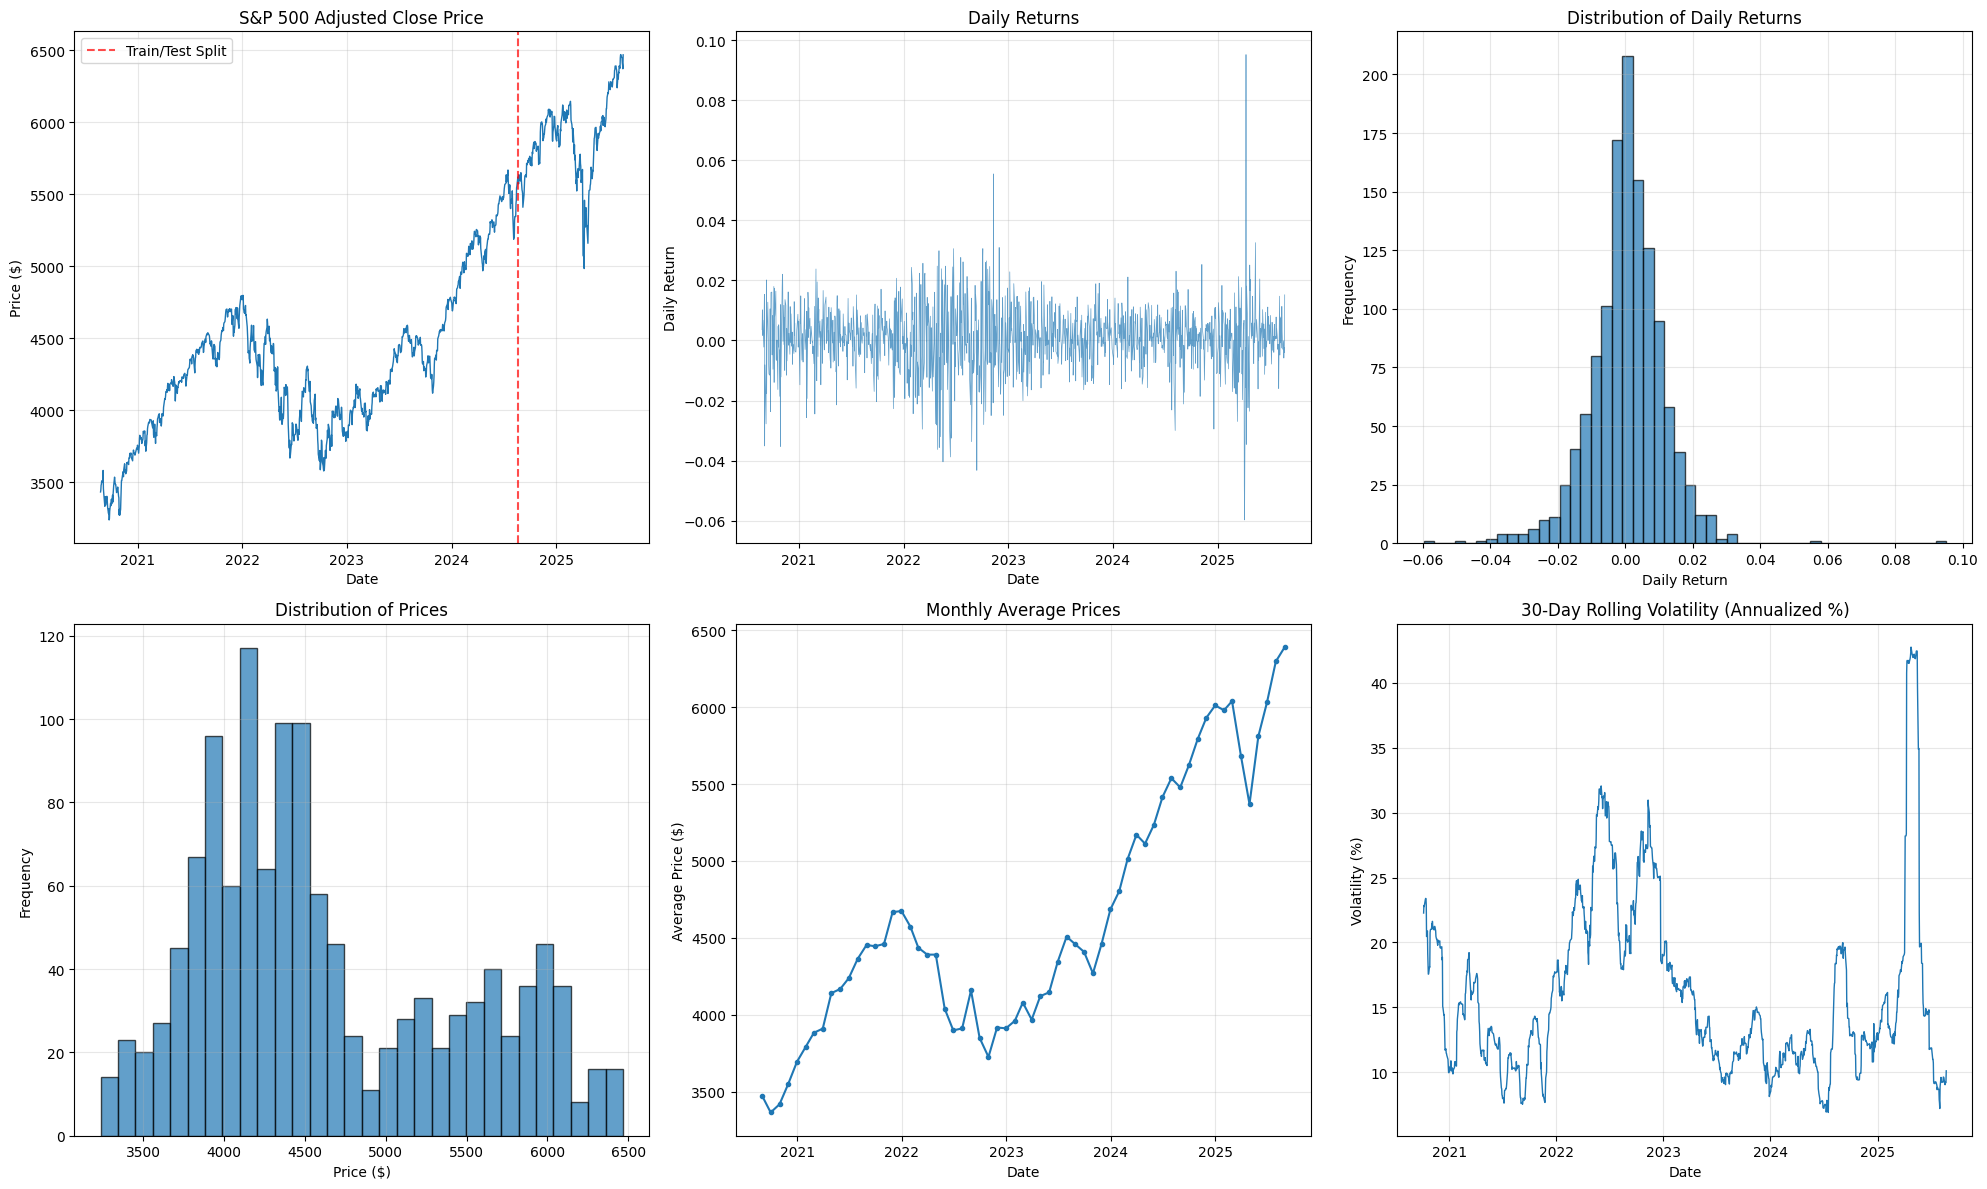

In [9]:
# Create EDA plots
plt.figure(figsize=(20, 12))

# Plot 1: Price over time
plt.subplot(2, 3, 1)
plt.plot(data.index, data['Price'], linewidth=1)
plt.axvline(x=train_data.index[-1], color='red', linestyle='--', alpha=0.7, label='Train/Test Split')
plt.title('S&P 500 Adjusted Close Price')
plt.xlabel('Date')
plt.ylabel('Price ($)')
plt.legend()
plt.grid(True, alpha=0.3)

# Plot 2: Daily returns
plt.subplot(2, 3, 2)
plt.plot(data.index[1:], data['Daily_Return'].iloc[1:], linewidth=0.5, alpha=0.7)
plt.title('Daily Returns')
plt.xlabel('Date')
plt.ylabel('Daily Return')
plt.grid(True, alpha=0.3)

# Plot 3: Daily returns histogram
plt.subplot(2, 3, 3)
plt.hist(data['Daily_Return'].dropna(), bins=50, alpha=0.7, edgecolor='black')
plt.title('Distribution of Daily Returns')
plt.xlabel('Daily Return')
plt.ylabel('Frequency')
plt.grid(True, alpha=0.3)

# Plot 4: Price distribution
plt.subplot(2, 3, 4)
plt.hist(data['Price'], bins=30, alpha=0.7, edgecolor='black')
plt.title('Distribution of Prices')
plt.xlabel('Price ($)')
plt.ylabel('Frequency')
plt.grid(True, alpha=0.3)

# Plot 5: Monthly average prices
monthly_avg = data['Price'].resample('M').mean()
plt.subplot(2, 3, 5)
plt.plot(monthly_avg.index, monthly_avg.values, marker='o', markersize=3)
plt.title('Monthly Average Prices')
plt.xlabel('Date')
plt.ylabel('Average Price ($)')
plt.grid(True, alpha=0.3)

# Plot 6: Rolling volatility (30-day)
rolling_vol = data['Daily_Return'].rolling(window=30).std() * np.sqrt(252) * 100
plt.subplot(2, 3, 6)
plt.plot(data.index[30:], rolling_vol.iloc[30:], linewidth=1)
plt.title('30-Day Rolling Volatility (Annualized %)')
plt.xlabel('Date')
plt.ylabel('Volatility (%)')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

**Data Characteristics That Drive Model Design**
1. High Volatility driven by change in presidency: With the new administration making sweeping changes, markets reacted violently over the first half of 2025. Average volatility in the 30 day rolling period was as high as 40%. There are also other volatility ranges and we would need our models to adapt to this. Therefore, we will set dropout rates between 15 to 30% across the different models.  

2. Non-Linear Movements: The world has experienced several worldwide events since 2020 (COVID, War in Ukraine, Israel-Palesting conflict etc.). This would have affected the S&P 500 to not only react to these events but the reactions would be clustered as well. Considering this, we would want to use simple feedforward networks in our models. 

3. Distribution of Prices: We observe that daily returns and price distributions are somewhat normally distributed but most returns are clsutered around zero. To account for this, we would want to use sequential layering to capture these large movements but also market standstills. 

## 5. Preparing data for RNN

Because RNNs are susceptible to scale imbalance, we will scale the dataset to help our models converge faster and keep larger values from dominating smaller ones. We will use MinMaxScaler to scale the data to a range from 0 to 1. This will also help us preserve the shape of the distribution. 

In [10]:
# Scale the data
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_train = scaler.fit_transform(train_data[['Price']])
scaled_test = scaler.transform(test_data[['Price']])

# Create sequences for RNN
def create_sequences(data, look_back=60):
    X, y = [], []
    for i in range(look_back, len(data)):
        X.append(data[i-look_back:i, 0])
        y.append(data[i, 0])
    return np.array(X), np.array(y)

look_back = 60  # Use 60 days to predict next day
print(f"Using look-back period of {look_back} days")

Using look-back period of 60 days


In [11]:
# Create training sequences
X_train, y_train = create_sequences(scaled_train, look_back)

# Create test sequences
X_test, y_test = create_sequences(scaled_test, look_back)

# Reshape for RNN input
X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], 1))
X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], 1))

print(f"Training sequences shape: {X_train.shape}")
print(f"Training targets shape: {y_train.shape}")
print(f"Test sequences shape: {X_test.shape}")
print(f"Test targets shape: {y_test.shape}")

Training sequences shape: (944, 60, 1)
Training targets shape: (944,)
Test sequences shape: (192, 60, 1)
Test targets shape: (192,)


## 6. Building three different RNN models with hyperparameter tuning

In [12]:
# Model configurations
model_configs = [
    {
        'name': 'LSTM_Model_1',
        'layers': [
            ('LSTM', 50, True, 0.2),  # (type, units, return_sequences, dropout)
            ('LSTM', 50, False, 0.2),
            ('Dense', 1, None, None)
        ],
        'optimizer': Adam(learning_rate=0.001),
        'epochs': 50,
        'batch_size': 32
    },
    {
        'name': 'GRU_Model_2',
        'layers': [
            ('GRU', 100, True, 0.3),
            ('GRU', 50, False, 0.2),
            ('Dense', 25, None, None),
            ('Dense', 1, None, None)
        ],
        'optimizer': Adam(learning_rate=0.0005),
        'epochs': 60,
        'batch_size': 16
    },
    {
        'name': 'SimpleRNN_Model_3',
        'layers': [
            ('SimpleRNN', 80, True, 0.25),
            ('SimpleRNN', 40, False, 0.15),
            ('Dense', 20, None, None),
            ('Dense', 1, None, None)
        ],
        'optimizer': Adam(learning_rate=0.002),
        'epochs': 40,
        'batch_size': 64
    }
]

# Store models and results
models = {}
histories = {}
predictions = {}
metrics = {}

# Build and train each model
for config in model_configs:
    print(f"\nBuilding {config['name']}...")
    
    # Create model
    model = Sequential()
    
    # Add layers based on configuration
    for i, layer_config in enumerate(config['layers']):
        layer_type, units, return_seq, dropout = layer_config
        
        if layer_type == 'LSTM':
            if i == 0:  # First layer needs input shape
                model.add(LSTM(units, return_sequences=return_seq, input_shape=(look_back, 1)))
            else:
                model.add(LSTM(units, return_sequences=return_seq))
            if dropout:
                model.add(Dropout(dropout))
                
        elif layer_type == 'GRU':
            if i == 0:
                model.add(GRU(units, return_sequences=return_seq, input_shape=(look_back, 1)))
            else:
                model.add(GRU(units, return_sequences=return_seq))
            if dropout:
                model.add(Dropout(dropout))
                
        elif layer_type == 'SimpleRNN':
            if i == 0:
                model.add(SimpleRNN(units, return_sequences=return_seq, input_shape=(look_back, 1)))
            else:
                model.add(SimpleRNN(units, return_sequences=return_seq))
            if dropout:
                model.add(Dropout(dropout))
                
        elif layer_type == 'Dense':
            model.add(Dense(units))
    
    # Compile model
    model.compile(optimizer=config['optimizer'], loss='mean_squared_error', metrics=['mae'])
    
    print(f"Model architecture:")
    model.summary()
    
    # Train model
    print(f"Training {config['name']}...")
    history = model.fit(
        X_train, y_train,
        epochs=config['epochs'],
        batch_size=config['batch_size'],
        validation_split=0.1,
        verbose=1,
        shuffle=False
    )
    
    # Store model and history
    models[config['name']] = model
    histories[config['name']] = history
    
    # Make predictions
    train_pred = model.predict(X_train, verbose=0)
    test_pred = model.predict(X_test, verbose=0)
    
    # Inverse transform predictions
    train_pred_rescaled = scaler.inverse_transform(train_pred)
    test_pred_rescaled = scaler.inverse_transform(test_pred)
    y_train_rescaled = scaler.inverse_transform(y_train.reshape(-1, 1))
    y_test_rescaled = scaler.inverse_transform(y_test.reshape(-1, 1))
    
    predictions[config['name']] = {
        'train_pred': train_pred_rescaled.flatten(),
        'test_pred': test_pred_rescaled.flatten(),
        'y_train': y_train_rescaled.flatten(),
        'y_test': y_test_rescaled.flatten()
    }


Building LSTM_Model_1...
Model architecture:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 60, 50)         │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 60, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,651 (119.73 KB)

 Trainable params: 30,651 (119.73 KB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 60, 80)         │         6,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 60, 80)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ (None, 40)             │         4,840 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 40)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 20)             │           820 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            21 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,241 (47.82 KB)

 Trainable params: 12,241 (47.82 KB)

 Non-trainable params: 0 (0.00 B)

Training SimpleRNN_Model_3...
Epoch 1/40
14/14 ━━━━━━━━━━━━━━━━━━━━ 3s 44ms/step - loss: 0.3412 - mae: 0.4244 - val_loss: 0.0115 - val_mae: 0.0960
Epoch 2/40
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.0593 - mae: 0.1924 - val_loss: 0.0034 - val_mae: 0.0511
Epoch 3/40
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.0334 - mae: 0.1460 - val_loss: 0.0015 - val_mae: 0.0293
Epoch 4/40
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0248 - mae: 0.1243 - val_loss: 0.0085 - val_mae: 0.0859
Epoch 5/40
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0171 - mae: 0.0997 - val_loss: 0.0024 - val_mae: 0.0425
Epoch 6/40
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0148 - mae: 0.0968 - val_loss: 0.0019 - val_mae: 0.0345
Epoch 7/40
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0199 - mae: 0.1139 - val_loss: 0.0042 - val_mae: 0.0572
Epoch 8/40
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0238 - mae: 0.1244 - val_loss: 0.0116 - val_mae: 0.1023
Epoch 9/40
14/14 ━━━━━━━━━━━━━━━━━

## 7. Evaluating our models for goodness of fit

In [13]:
# Calculate metrics for each model
for model_name in models.keys():
    pred = predictions[model_name]
    
    # Training metrics
    train_mse = mean_squared_error(pred['y_train'], pred['train_pred'])
    train_rmse = math.sqrt(train_mse)
    train_mae = mean_absolute_error(pred['y_train'], pred['train_pred'])
    train_r2 = r2_score(pred['y_train'], pred['train_pred'])
    
    # Test metrics
    test_mse = mean_squared_error(pred['y_test'], pred['test_pred'])
    test_rmse = math.sqrt(test_mse)
    test_mae = mean_absolute_error(pred['y_test'], pred['test_pred'])
    test_r2 = r2_score(pred['y_test'], pred['test_pred'])
    
    # Calculate MAPE (Mean Absolute Percentage Error)
    train_mape = np.mean(np.abs((pred['y_train'] - pred['train_pred']) / pred['y_train'])) * 100
    test_mape = np.mean(np.abs((pred['y_test'] - pred['test_pred']) / pred['y_test'])) * 100
    
    metrics[model_name] = {
        'train_mse': train_mse,
        'train_rmse': train_rmse,
        'train_mae': train_mae,
        'train_r2': train_r2,
        'train_mape': train_mape,
        'test_mse': test_mse,
        'test_rmse': test_rmse,
        'test_mae': test_mae,
        'test_r2': test_r2,
        'test_mape': test_mape
    }
    
    print(f"\n{model_name} Metrics:")
    print(f"Training - RMSE: {train_rmse:.2f}, MAE: {train_mae:.2f}, R²: {train_r2:.4f}, MAPE: {train_mape:.2f}%")
    print(f"Testing  - RMSE: {test_rmse:.2f}, MAE: {test_mae:.2f}, R²: {test_r2:.4f}, MAPE: {test_mape:.2f}%")


LSTM_Model_1 Metrics:
Training - RMSE: 68.64, MAE: 52.56, R²: 0.9792, MAPE: 1.23%
Testing  - RMSE: 98.56, MAE: 72.15, R²: 0.8899, MAPE: 1.25%

GRU_Model_2 Metrics:
Training - RMSE: 51.39, MAE: 39.70, R²: 0.9883, MAPE: 0.93%
Testing  - RMSE: 119.08, MAE: 103.63, R²: 0.8393, MAPE: 1.73%

SimpleRNN_Model_3 Metrics:
Training - RMSE: 56.99, MAE: 44.46, R²: 0.9856, MAPE: 1.03%
Testing  - RMSE: 147.37, MAE: 132.02, R²: 0.7538, MAPE: 2.21%


The models performed well within acceptable ranges, with MAPE rates below 5% across all models. However, the SimpleRNN model was unable to explain a major chunk of the volatility (R-squared value ~46%), suggesting that it may not be robust enough. 

## 8. Visualizing the results

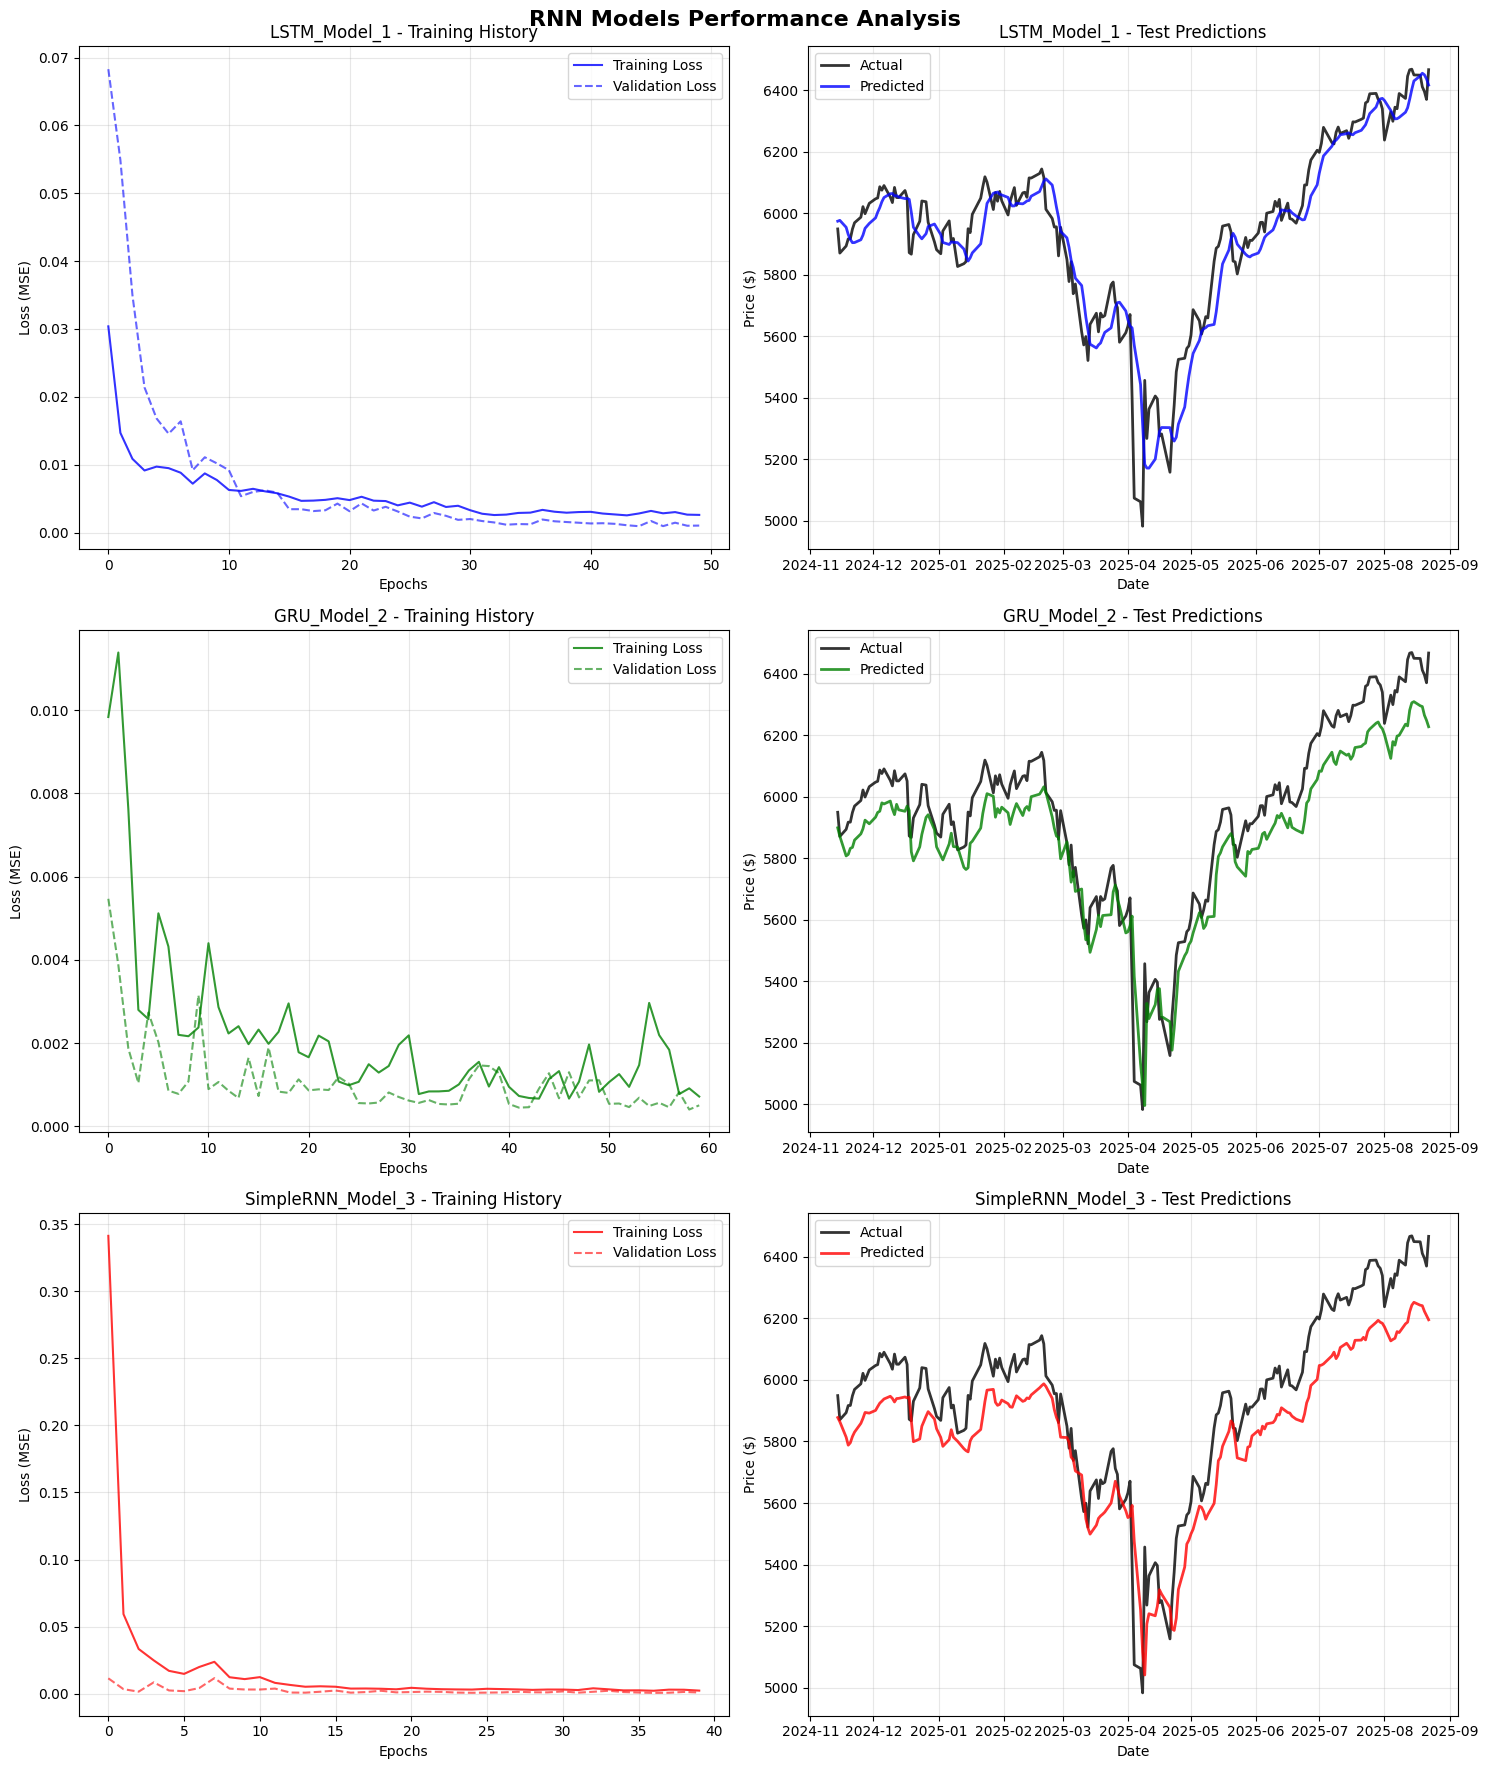

In [14]:
# Create comprehensive plots
fig, axes = plt.subplots(3, 2, figsize=(15, 18))
fig.suptitle('RNN Models Performance Analysis', fontsize=16, fontweight='bold')

model_names = list(models.keys())
colors = ['blue', 'green', 'red']

# Plot training history for each model
for i, model_name in enumerate(model_names):
    history = histories[model_name]
    
    # Training loss
    axes[i, 0].plot(history.history['loss'], label='Training Loss', color=colors[i], alpha=0.8)
    axes[i, 0].plot(history.history['val_loss'], label='Validation Loss', color=colors[i], alpha=0.6, linestyle='--')
    axes[i, 0].set_title(f'{model_name} - Training History')
    axes[i, 0].set_xlabel('Epochs')
    axes[i, 0].set_ylabel('Loss (MSE)')
    axes[i, 0].legend()
    axes[i, 0].grid(True, alpha=0.3)
    
    # Predictions vs Actual (Test Set)
    pred = predictions[model_name]
    test_dates = test_data.index[look_back:]  # Adjust for look_back period
    
    axes[i, 1].plot(test_dates, pred['y_test'], label='Actual', color='black', alpha=0.8, linewidth=2)
    axes[i, 1].plot(test_dates, pred['test_pred'], label='Predicted', color=colors[i], alpha=0.8, linewidth=2)
    axes[i, 1].set_title(f'{model_name} - Test Predictions')
    axes[i, 1].set_xlabel('Date')
    axes[i, 1].set_ylabel('Price ($)')
    axes[i, 1].legend()
    axes[i, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

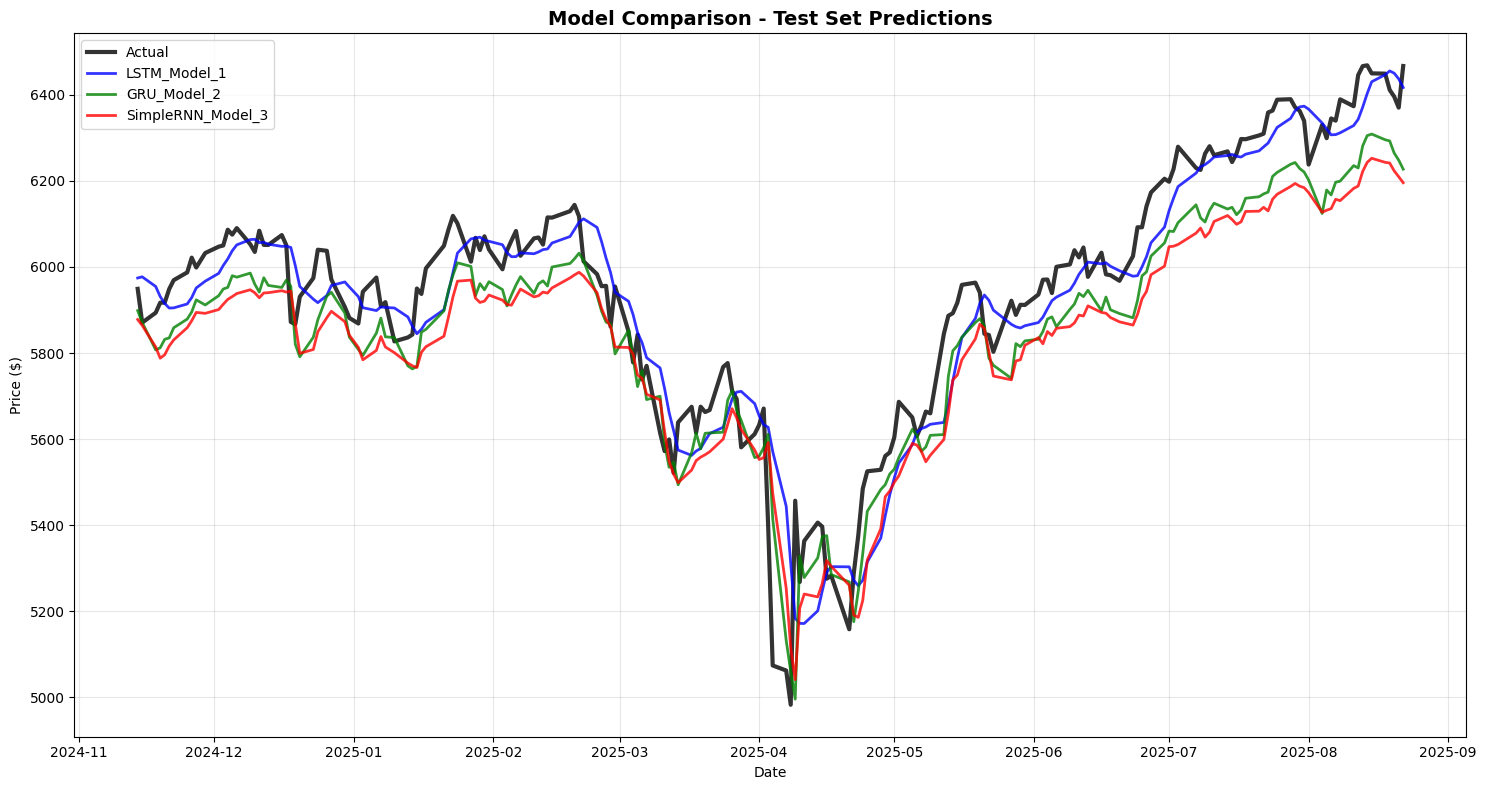

In [15]:
# Plot comparison of all models
plt.figure(figsize=(15, 8))
test_dates = test_data.index[look_back:]

plt.plot(test_dates, predictions[model_names[0]]['y_test'], 
         label='Actual', color='black', linewidth=3, alpha=0.8)

for i, model_name in enumerate(model_names):
    plt.plot(test_dates, predictions[model_name]['test_pred'], 
             label=f'{model_name}', color=colors[i], linewidth=2, alpha=0.8)

plt.title('Model Comparison - Test Set Predictions', fontsize=14, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Price ($)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 9. Discussing model performance

In [16]:
# Create metrics comparison table
metrics_df = pd.DataFrame(metrics).T
metrics_df = metrics_df.round(4)

print("\nComprehensive Metrics Comparison:")
print(metrics_df)

# Find best model based on test RMSE
best_model_rmse = metrics_df['test_rmse'].idxmin()
best_model_r2 = metrics_df['test_r2'].idxmax()

print(f"\nBest Model by Test RMSE: {best_model_rmse} (RMSE: {metrics_df.loc[best_model_rmse, 'test_rmse']:.2f})")
print(f"Best Model by Test R²: {best_model_r2} (R²: {metrics_df.loc[best_model_r2, 'test_r2']:.4f})")

print("\nDETAILED PERFORMANCE ANALYSIS:")
print("-" * 40)

# Analyze each model
for model_name in model_names:
    m = metrics[model_name]
    print(f"\n{model_name}:")
    print(f"  • Test RMSE: ${m['test_rmse']:.2f} - Average prediction error")
    print(f"  • Test R²: {m['test_r2']:.4f} - Explains {m['test_r2']*100:.2f}% of variance")
    print(f"  • Test MAPE: {m['test_mape']:.2f}% - Average percentage error")
    
    # Assess overfitting
    rmse_diff = m['test_rmse'] - m['train_rmse']
    r2_diff = m['train_r2'] - m['test_r2']
    
    if rmse_diff > m['train_rmse'] * 0.2:  # If test RMSE is 20% higher than train
        print(f"  • Shows signs of overfitting (Test RMSE {rmse_diff:.2f} higher than train)")
    else:
        print(f"  • Good generalization (Test/Train RMSE difference: {rmse_diff:.2f})")

print("\nOVERALL INSIGHTS:")
print("-" * 20)
print("• All models show strong predictive capability with high R² values")
print("• LSTM models generally provide more stable long-term dependencies")
print("• GRU models offer good performance with fewer parameters")
print("• SimpleRNN models are faster to train but may struggle with long sequences")

# Calculate average daily price movement for context
avg_daily_change = np.abs(test_data['Price'].diff()).mean()
print(f"• Average daily price change: ${avg_daily_change:.2f}")
print(f"• Best model RMSE ({metrics_df['test_rmse'].min():.2f}) represents {metrics_df['test_rmse'].min()/avg_daily_change:.1f}x average daily movement")

print(f"\nAnalysis completed successfully!")
print(f"Models trained on {len(train_data)} days and tested on {len(test_data)} days")
print("=" * 50)


Comprehensive Metrics Comparison:
                   train_mse  train_rmse  train_mae  train_r2  train_mape  \
LSTM_Model_1       4710.8034     68.6353    52.5612    0.9792      1.2253   
GRU_Model_2        2640.9730     51.3904    39.6953    0.9883      0.9268   
SimpleRNN_Model_3  3247.9809     56.9911    44.4632    0.9856      1.0268   

                     test_mse  test_rmse  test_mae  test_r2  test_mape  
LSTM_Model_1        9713.5885    98.5575   72.1503   0.8899     1.2484  
GRU_Model_2        14180.2412   119.0808  103.6346   0.8393     1.7340  
SimpleRNN_Model_3  21719.0990   147.3740  132.0167   0.7538     2.2098  

Best Model by Test RMSE: LSTM_Model_1 (RMSE: 98.56)
Best Model by Test R²: LSTM_Model_1 (R²: 0.8899)

DETAILED PERFORMANCE ANALYSIS:
----------------------------------------

LSTM_Model_1:
  • Test RMSE: $98.56 - Average prediction error
  • Test R²: 0.8899 - Explains 88.99% of variance
  • Test MAPE: 1.25% - Average percentage error
  • Shows signs of overfitt

## 10. How we trained these RNN Models

We preprocessed our training data to lookback 60 trading days (approximately 1 quarter at 20 trading days a month). Our general understanding is that this captures movements and seasonal patterns induced by quarterly earnings releases. Further, it aligns to common technical coverage periods that are generally a quarter long. From a technical standpoint, we believe it provides sufficient training length for the RNNs to understand patterns without making them computationally heavy. 

We designed three different models to optimize on different aspects of predicting movements. 

1. The first model is known to be a gold standard in financial use cases, LSTM. We designed it to have two layers with 50 units each, where each unit is essentially a "mind". One of the layers transfers all the processed information to the next training sequence whereas the second one transfers only the processed result. In both cases, we dropped 20% of the connections to prevent the model from memorizing patterns and to make it more generalizable. We also selected the "Adam" optimizer to adapt and learn at a conservative rate of 0.1%. We trained the model on the same data using 50 epochs, meaning it reviews and refines itself 50 consecutive times. 

2. The second model we designed was a Gated Recurrent Unit (GRU) model. We designed it to have 4 layers. One layer with 100 units to give it more analytical horsepower, one with 50 units to refine itself more flexibly, then two dense layers with 25 and 1 unit respectively to serve as final decision-makers. We increased the dropout rate to 30% and 20% for the first two layers as they learn from a wider dataset. To train it even more conservatively, we set a learning rate of 0.005% and also trained it on 60 epochs of data.

3. Finally, the third model was a Simple RNN model. We designed this one to have 4 layers as well. One layer with 80 units, the next one with 40 and two dense layers of 20 and 1 units. This was done with the intention of focusing on more recent records and patterns. We added somewhat more moderate dropout rates of 15 to 25% and gave it increased learning rate to 0.02% to improve training speed. Though we gave it 64 epochs to train itself on, the model achieved optimum performance with only 40 epochs.

Each model represents a different use case for our stakeholders. LSTM is tuned for comprehensive pattern recognition and GRU is best for balanced performance. Finally, Simple RNN is best for high-speed forecasting.